# PhyloP Conservation Analysis for Translons

Comprehensive conservation analysis using PhyloP scores (30way, 100way, 470way) for any translon dataset in BigBed format.

## Install Dependencies

Run this first in a clean Python 3.13 venv

In [1]:
!python -m pip install pyBigWig numpy pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


## Configuration

In [2]:
from pathlib import Path

BIGBED_URL = "https://ftp.ebi.ac.uk/pub/databases/gencode/riboseq_orfs/data/Ribo-seq_ORFs.bb"
BIGBED_PATH = Path("data/Ribo-seq_ORFs.bb")

PHYLOP_PATHS = {
    '30way': Path('data/phylop/hg38.phyloP30way.bw'),
    '100way': Path('data/phylop/hg38.phyloP100way.bw'),
    '470way': Path('data/phylop/hg38.phyloP470way.bw')
}

PHYLOP_URLS = {
    '30way': 'http://hgdownload.cse.ucsc.edu/goldenpath/hg38/phyloP30way/hg38.phyloP30way.bw',
    # '100way': 'http://hgdownload.cse.ucsc.edu/goldenpath/hg38/phyloP100way/hg38.phyloP100way.bw',
    # '470way': 'http://hgdownload.cse.ucsc.edu/goldenpath/hg38/phyloP470way/hg38.phyloP470way.bw'
}

FLANK_SIZE = 50
OUTPUT_PREFIX = 'results/phylop/translon_phylop'

## Import Dependencies

In [3]:
import pyBigWig
import numpy as np
import pandas as pd
import subprocess
import urllib.request
from pathlib import Path

## Check and Download Required Files

In [4]:
def download_file(url, output_path):
    output_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {url}...")
    urllib.request.urlretrieve(url, output_path)
    print(f"Saved to {output_path}")

if not BIGBED_PATH.exists():
    download_file(BIGBED_URL, BIGBED_PATH)
else:
    print(f"BigBed file found: {BIGBED_PATH}")

BigBed file found: data/Ribo-seq_ORFs.bb


In [5]:
available_phylop = {}

for name, path in PHYLOP_PATHS.items():
    if path.exists():
        print(f"✓ PhyloP {name}: {path}")
        available_phylop[name] = path
    else:
        print(f"✗ PhyloP {name}: Not found at {path}")
        print(f"  Downloading from {PHYLOP_URLS[name]}...")
        download_file(PHYLOP_URLS[name], path)
        available_phylop[name] = path

if not available_phylop:
    raise FileNotFoundError("No PhyloP files found. Please check downloads.")

print(f"\n✓ Ready with {len(available_phylop)} PhyloP dataset(s)")

✓ PhyloP 30way: data/phylop/hg38.phyloP30way.bw

✓ Ready with 1 PhyloP dataset(s)


## Extract Translon Coordinates from BigBed

In [6]:
def extract_translons_from_bigbed(bigbed_path):
    bed_path = str(bigbed_path).replace('.bb', '.bed')
    subprocess.run(['/nfs/production/flicek/ensembl/genebuild/jackt/projects/translon-conservation/bigBedToBed', str(bigbed_path), bed_path], check=True)
    
    translons = pd.read_csv(
        bed_path, 
        sep='\t', 
        header=None,
        names=['chrom', 'start', 'end', 'name', 'score', 'strand',
               'thickStart', 'thickEnd', 'itemRgb', 'blockCount',
               'blockSizes', 'blockStarts']
    )
    
    return translons

def extract_translons_from_bigbed(bigbed_path):
    bed_path = str(bigbed_path).replace('.bb', '.bed')
    subprocess.run(['/nfs/production/flicek/ensembl/genebuild/jackt/projects/translon-conservation/bigBedToBed', str(bigbed_path), bed_path], check=True)
    
    translons = pd.read_csv(
        bed_path, 
        sep='\t', 
        header=None,
        usecols=[0, 1, 2, 3, 4, 5],
        names=['chrom', 'start', 'end', 'name', 'score', 'strand']
    )
    
    return translons

In [7]:
translons = extract_translons_from_bigbed(BIGBED_PATH)
print(f"Extracted {len(translons):,} translons")
print(f"\nFirst few entries:")
translons.head()

Extracted 7,264 translons

First few entries:


,chrom,start,end,name,score,strand
0,chr1,826870,829027,c1norep1,0,+
1,chr1,829023,829092,c1norep2,0,+
2,chr1,847671,850321,c1riboseqorf1,0,+
3,chr1,847671,852067,c1riboseqorf2,0,+
4,chr1,852070,852699,c1riboseqorf3,0,+


## Core Functions: Extract PhyloP Scores

In [8]:
def get_phylop_scores_with_flanks(chrom, start, end, bw, flank_size=100):
    upstream_scores = bw.values(chrom, max(0, start - flank_size), start, numpy=True)
    feature_scores = bw.values(chrom, start, end, numpy=True)
    downstream_scores = bw.values(chrom, end, end + flank_size, numpy=True)
    
    upstream_scores = upstream_scores[~np.isnan(upstream_scores)] if upstream_scores is not None else np.array([])
    feature_scores = feature_scores[~np.isnan(feature_scores)] if feature_scores is not None else np.array([])
    downstream_scores = downstream_scores[~np.isnan(downstream_scores)] if downstream_scores is not None else np.array([])
    
    return upstream_scores, feature_scores, downstream_scores

## Core Functions: Nucleotide-Level Metrics

In [9]:
def max_run_length(boolean_array):
    if len(boolean_array) == 0:
        return 0
    
    max_run = current_run = 0
    for val in boolean_array:
        if val:
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 0
    return max_run

In [10]:
def calculate_nucleotide_metrics(scores, prefix=''):
    if len(scores) == 0:
        return {f'{prefix}n_bases': 0}
    
    return {
        f'{prefix}n_bases': len(scores),
        f'{prefix}mean': np.mean(scores),
        f'{prefix}median': np.median(scores),
        f'{prefix}std': np.std(scores),
        f'{prefix}min': np.min(scores),
        f'{prefix}max': np.max(scores),
        f'{prefix}q25': np.percentile(scores, 25),
        f'{prefix}q75': np.percentile(scores, 75),
        f'{prefix}q95': np.percentile(scores, 95),
        f'{prefix}q05': np.percentile(scores, 5),
        f'{prefix}frac_positive': np.sum(scores > 0) / len(scores),
        f'{prefix}frac_conserved_weak': np.sum(scores > 0.5) / len(scores),
        f'{prefix}frac_conserved_moderate': np.sum(scores > 1.0) / len(scores),
        f'{prefix}frac_conserved_strong': np.sum(scores > 1.5) / len(scores),
        f'{prefix}frac_conserved_very_strong': np.sum(scores > 2.0) / len(scores),
        f'{prefix}frac_negative': np.sum(scores < 0) / len(scores),
        f'{prefix}frac_depleted_weak': np.sum(scores < -0.5) / len(scores),
        f'{prefix}frac_depleted_moderate': np.sum(scores < -1.0) / len(scores),
        f'{prefix}frac_depleted_strong': np.sum(scores < -1.5) / len(scores),
        f'{prefix}skewness': pd.Series(scores).skew(),
        f'{prefix}kurtosis': pd.Series(scores).kurtosis(),
        f'{prefix}max_conserved_run': max_run_length(scores > 0),
        f'{prefix}max_depleted_run': max_run_length(scores < 0),
    }

## Core Functions: Codon-Level Metrics

In [11]:
def calculate_codon_metrics(scores, strand):
    if len(scores) == 0:
        return {}
    
    if strand == '-':
        scores = scores[::-1]
    
    n_codons = len(scores) // 3
    if n_codons == 0:
        return {'n_codons': 0}
    
    trimmed_scores = scores[:n_codons * 3]
    scores_2d = trimmed_scores.reshape(-1, 3)
    
    return {
        'n_codons': n_codons,
        'codon_pos1_mean': np.mean(scores_2d[:, 0]),
        'codon_pos2_mean': np.mean(scores_2d[:, 1]),
        'codon_pos3_mean': np.mean(scores_2d[:, 2]),
        'codon_pos1_median': np.median(scores_2d[:, 0]),
        'codon_pos2_median': np.median(scores_2d[:, 1]),
        'codon_pos3_median': np.median(scores_2d[:, 2]),
        'codon_pos1_std': np.std(scores_2d[:, 0]),
        'codon_pos2_std': np.std(scores_2d[:, 1]),
        'codon_pos3_std': np.std(scores_2d[:, 2]),
        'wobble_depletion_mean': (np.mean(scores_2d[:, 0]) + np.mean(scores_2d[:, 1])) / 2 - np.mean(scores_2d[:, 2]),
        'wobble_depletion_median': (np.median(scores_2d[:, 0]) + np.median(scores_2d[:, 1])) / 2 - np.median(scores_2d[:, 2]),
        'codon_pos1_frac_positive': np.sum(scores_2d[:, 0] > 0) / n_codons,
        'codon_pos2_frac_positive': np.sum(scores_2d[:, 1] > 0) / n_codons,
        'codon_pos3_frac_positive': np.sum(scores_2d[:, 2] > 0) / n_codons,
        'codon_pos1_frac_conserved': np.sum(scores_2d[:, 0] > 1.5) / n_codons,
        'codon_pos2_frac_conserved': np.sum(scores_2d[:, 1] > 1.5) / n_codons,
        'codon_pos3_frac_conserved': np.sum(scores_2d[:, 2] > 1.5) / n_codons,
        'mean_codon_mean': np.mean(np.mean(scores_2d, axis=1)),
        'mean_codon_max': np.mean(np.max(scores_2d, axis=1)),
        'mean_codon_min': np.mean(np.min(scores_2d, axis=1)),
        'frac_codons_all_positive': np.sum(np.all(scores_2d > 0, axis=1)) / n_codons,
        'frac_codons_all_conserved': np.sum(np.all(scores_2d > 1.5, axis=1)) / n_codons,
        'frac_codons_all_negative': np.sum(np.all(scores_2d < 0, axis=1)) / n_codons,
    }

## Core Functions: Flanking Context Comparison

In [12]:
def calculate_flanking_context(feature_scores, upstream_scores, downstream_scores):
    if len(feature_scores) == 0:
        return {}
    
    feature_mean = np.mean(feature_scores)
    metrics = {}
    
    if len(upstream_scores) > 0:
        upstream_mean = np.mean(upstream_scores)
        metrics['upstream_mean'] = upstream_mean
        metrics['upstream_vs_feature_diff'] = feature_mean - upstream_mean
        metrics['upstream_vs_feature_ratio'] = feature_mean / upstream_mean if upstream_mean != 0 else np.nan
    else:
        metrics.update({'upstream_mean': np.nan, 'upstream_vs_feature_diff': np.nan, 'upstream_vs_feature_ratio': np.nan})
    
    if len(downstream_scores) > 0:
        downstream_mean = np.mean(downstream_scores)
        metrics['downstream_mean'] = downstream_mean
        metrics['downstream_vs_feature_diff'] = feature_mean - downstream_mean
        metrics['downstream_vs_feature_ratio'] = feature_mean / downstream_mean if downstream_mean != 0 else np.nan
    else:
        metrics.update({'downstream_mean': np.nan, 'downstream_vs_feature_diff': np.nan, 'downstream_vs_feature_ratio': np.nan})
    
    if len(upstream_scores) > 0 and len(downstream_scores) > 0:
        flanking_mean = np.mean(np.concatenate([upstream_scores, downstream_scores]))
        metrics['flanking_mean'] = flanking_mean
        metrics['feature_vs_flanking_diff'] = feature_mean - flanking_mean
        metrics['feature_vs_flanking_ratio'] = feature_mean / flanking_mean if flanking_mean != 0 else np.nan
        metrics['more_conserved_than_flanks'] = (feature_mean > upstream_mean) and (feature_mean > downstream_mean)
        metrics['specifically_conserved'] = (feature_mean - flanking_mean) > 0.5
    else:
        metrics.update({
            'flanking_mean': np.nan,
            'feature_vs_flanking_diff': np.nan,
            'feature_vs_flanking_ratio': np.nan,
            'more_conserved_than_flanks': False,
            'specifically_conserved': False
        })
    
    return metrics

## Main Analysis Function

In [13]:
def analyze_translons_phylop(translons_df, phylop_paths, flank_size=100):
    all_results = []
    
    for phylop_name, phylop_path in phylop_paths.items():
        print(f"\nProcessing {phylop_name}...")
        bw = pyBigWig.open(str(phylop_path))
        
        for idx, translon in translons_df.iterrows():
            try:
                upstream_scores, feature_scores, downstream_scores = get_phylop_scores_with_flanks(
                    translon['chrom'], int(translon['start']), int(translon['end']), bw, flank_size
                )
                
                if len(feature_scores) == 0:
                    continue
                
                result = {
                    'translon_id': translon['name'],
                    'chrom': translon['chrom'],
                    'start': int(translon['start']),
                    'end': int(translon['end']),
                    'strand': translon['strand'],
                    'length': int(translon['end']) - int(translon['start']),
                    'phylop_dataset': phylop_name,
                    'flank_size': flank_size,
                }
                
                result.update(calculate_nucleotide_metrics(feature_scores, prefix='feature_'))
                result.update(calculate_nucleotide_metrics(upstream_scores, prefix='upstream_'))
                result.update(calculate_nucleotide_metrics(downstream_scores, prefix='downstream_'))
                result.update(calculate_codon_metrics(feature_scores, translon['strand']))
                result.update(calculate_flanking_context(feature_scores, upstream_scores, downstream_scores))
                result['feature_frac_coverage'] = len(feature_scores) / (int(translon['end']) - int(translon['start']))
                
                all_results.append(result)
                
            except Exception as e:
                print(f"  Error on {translon['name']}: {e}")
                continue
        
        bw.close()
        print(f"  Completed: {len([r for r in all_results if r['phylop_dataset'] == phylop_name])} translons")
    
    return pd.DataFrame(all_results)

## Run Analysis

In [14]:
Path(OUTPUT_PREFIX).parent.mkdir(parents=True, exist_ok=True)

results = analyze_translons_phylop(translons, available_phylop, FLANK_SIZE)

output_file = f"{OUTPUT_PREFIX}_comprehensive.tsv"
results.to_csv(output_file, sep='\t', index=False)
print(f"\nSaved {len(results):,} results to {output_file}")


Processing 30way...
  Completed: 7262 translons

Saved 7,262 results to results/phylop/translon_phylop_comprehensive.tsv


## Generate Summary Statistics

In [15]:
def print_summary(results_df):
    for dataset in results_df['phylop_dataset'].unique():
        df = results_df[results_df['phylop_dataset'] == dataset]
        
        print(f"\n{'='*80}")
        print(f"Dataset: {dataset}")
        print(f"{'='*80}")
        print(f"Translons analyzed: {len(df):,}")
        print(f"\nMean PhyloP: {df['feature_mean'].mean():.3f} ± {df['feature_mean'].std():.3f}")
        print(f"Median PhyloP: {df['feature_median'].median():.3f}")
        print(f"Fraction conserved (>0): {df['feature_frac_positive'].mean():.3f}")
        print(f"Fraction strongly conserved (>1.5): {df['feature_frac_conserved_strong'].mean():.3f}")
        
        strongly_conserved = (df['feature_mean'] > 1.5).sum()
        conserved = ((df['feature_mean'] > 0.5) & (df['feature_mean'] <= 1.5)).sum()
        neutral = ((df['feature_mean'] >= -0.5) & (df['feature_mean'] <= 0.5)).sum()
        depleted = (df['feature_mean'] < -0.5).sum()
        
        print(f"\nConservation categories:")
        print(f"  Strongly conserved (>1.5):  {strongly_conserved:6,} ({100*strongly_conserved/len(df):5.1f}%)")
        print(f"  Conserved (0.5 to 1.5):     {conserved:6,} ({100*conserved/len(df):5.1f}%)")
        print(f"  Neutral (-0.5 to 0.5):      {neutral:6,} ({100*neutral/len(df):5.1f}%)")
        print(f"  Depleted (<-0.5):           {depleted:6,} ({100*depleted/len(df):5.1f}%)")
        
        codon_df = df[df['n_codons'] > 0]
        if len(codon_df) > 0:
            print(f"\nCodon position means:")
            print(f"  Position 1: {codon_df['codon_pos1_mean'].mean():.3f}")
            print(f"  Position 2: {codon_df['codon_pos2_mean'].mean():.3f}")
            print(f"  Position 3: {codon_df['codon_pos3_mean'].mean():.3f}")
            print(f"  Wobble depletion: {codon_df['wobble_depletion_mean'].mean():.3f}")
        
        flanking_df = df[df['flanking_mean'].notna()]
        if len(flanking_df) > 0:
            print(f"\nFlanking context:")
            print(f"  Feature vs flanking diff: {flanking_df['feature_vs_flanking_diff'].mean():.3f}")
            print(f"  Specifically conserved: {flanking_df['specifically_conserved'].sum():,} ({100*flanking_df['specifically_conserved'].sum()/len(flanking_df):.1f}%)")
            print(f"  More conserved than both flanks: {flanking_df['more_conserved_than_flanks'].sum():,} ({100*flanking_df['more_conserved_than_flanks'].sum()/len(flanking_df):.1f}%)")

print_summary(results)


Dataset: 30way
Translons analyzed: 7,262

Mean PhyloP: 0.242 ± 0.300
Median PhyloP: 0.172
Fraction conserved (>0): 0.666
Fraction strongly conserved (>1.5): 0.000

Conservation categories:
  Strongly conserved (>1.5):       0 (  0.0%)
  Conserved (0.5 to 1.5):      1,393 ( 19.2%)
  Neutral (-0.5 to 0.5):       5,850 ( 80.6%)
  Depleted (<-0.5):               19 (  0.3%)

Codon position means:
  Position 1: 0.251
  Position 2: 0.226
  Position 3: 0.247
  Wobble depletion: -0.009

Flanking context:
  Feature vs flanking diff: -0.063
  Specifically conserved: 40 (0.6%)
  More conserved than both flanks: 1,672 (23.0%)


## Quick Visualization: Conservation Distribution

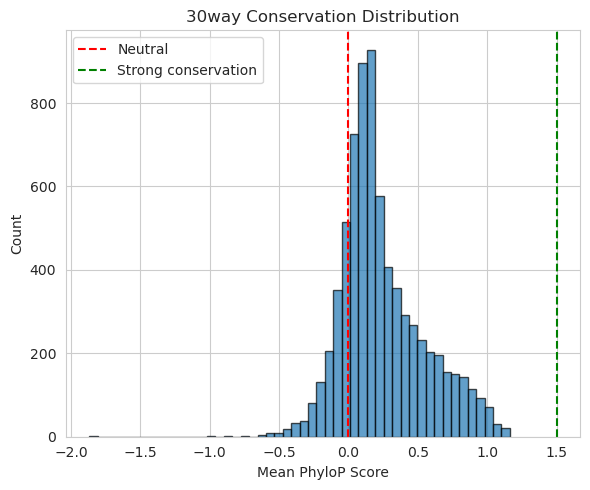

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, len(results['phylop_dataset'].unique()), figsize=(6*len(results['phylop_dataset'].unique()), 5))

if len(results['phylop_dataset'].unique()) == 1:
    axes = [axes]

for ax, dataset in zip(axes, results['phylop_dataset'].unique()):
    df = results[results['phylop_dataset'] == dataset]
    ax.hist(df['feature_mean'], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', label='Neutral')
    ax.axvline(1.5, color='green', linestyle='--', label='Strong conservation')
    ax.set_xlabel('Mean PhyloP Score')
    ax.set_ylabel('Count')
    ax.set_title(f'{dataset} Conservation Distribution')
    ax.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_PREFIX}_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

## Quick Visualization: Codon Position Conservation

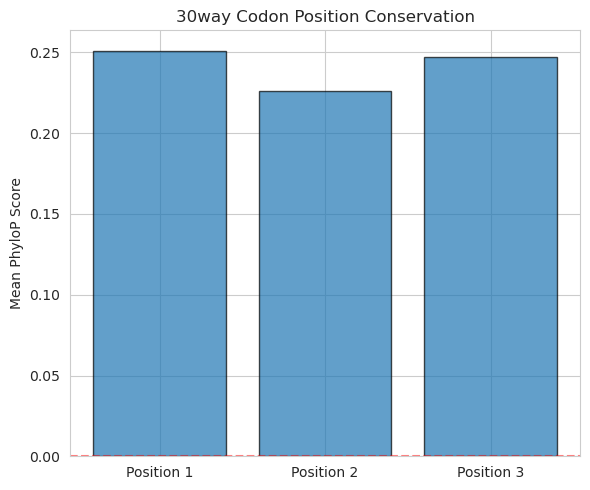

In [17]:
codon_results = results[results['n_codons'] > 0]

if len(codon_results) > 0:
    fig, axes = plt.subplots(1, len(codon_results['phylop_dataset'].unique()), figsize=(6*len(codon_results['phylop_dataset'].unique()), 5))
    
    if len(codon_results['phylop_dataset'].unique()) == 1:
        axes = [axes]
    
    for ax, dataset in zip(axes, codon_results['phylop_dataset'].unique()):
        df = codon_results[codon_results['phylop_dataset'] == dataset]
        positions = ['Position 1', 'Position 2', 'Position 3']
        means = [df['codon_pos1_mean'].mean(), df['codon_pos2_mean'].mean(), df['codon_pos3_mean'].mean()]
        
        ax.bar(positions, means, edgecolor='black', alpha=0.7)
        ax.axhline(0, color='red', linestyle='--', alpha=0.5)
        ax.set_ylabel('Mean PhyloP Score')
        ax.set_title(f'{dataset} Codon Position Conservation')
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_PREFIX}_codon_positions.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No translons with codon-level analysis available")